<a href="https://colab.research.google.com/github/Nharnharqwaci/Foxtrot-2-Final-project-/blob/main/Foxtrot_2_Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING THE NEEDED LIBRARIES FOR DATA MANIPULATION, ANALYSIS AND VISUALIZATION



In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import shap
import joblib


c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING THE DATASET AND PERFORMING BASIC EXPLORATORY DATA ANALYSIS(EDA)

This includes viewing the first few rows, last few rows, summary statistics,
checking the shape of the dataset, and identifying missing values.

In [2]:
fraud_df = pd.read_csv('./Bank_Transaction_Fraud_Detection.csv')
fraud_df

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,b8bdae19-296f-48b7-9104-e055d33a09ac,Vedhika Magar,Female,55,Dadra and Nagar Haveli and Daman and Diu,Diu,Diu Branch,Business,8d856bc7-4666-4509-a067-48d67500694a,08-01-2025,...,Restaurant,37475.11,Desktop/Laptop,"Diu, Dadra and Nagar Haveli and Daman and Diu",ATM,0,INR,+9192629XXXXXX,ATM withdrawal,vedhikaXXXXX@XXXXXXX.com
199996,635bc099-8a93-48ee-829a-bf2283fe8fda,Aashi Pai,Male,51,Manipur,Kangpokpi,Kangpokpi Branch,Business,f2890dbd-4e01-445d-97f5-ac56886e9037,01-01-2025,...,Groceries,53037.20,ATM,"Kangpokpi, Manipur",ATM,0,INR,+9198116XXXXXX,Subscription box,aashiXXX@XXXXXX.com
199997,c1b31cc2-0905-47e8-8cc5-6461d1f3ba33,Dayita Shan,Female,41,Chandigarh,Chandigarh,Chandigarh Branch,Savings,f714b758-7539-474d-b676-5fa7e2480141,28-01-2025,...,Health,96225.36,ATM,"Chandigarh, Chandigarh",Desktop,0,INR,+9192601XXXXXX,Charity donation,dayitaXXXX@XXXXXXX.com
199998,32bb8e66-f3fa-43bf-8242-dab9a6116310,Unnati Vyas,Female,28,Telangana,Nizamabad,Nizamabad Branch,Checking,f6903b6a-b582-47ea-95d5-aff16bdec950,08-01-2025,...,Electronics,89599.90,Voice Assistant,"Nizamabad, Telangana",Desktop,0,INR,+9197537XXXXXX,Tourist attraction payment,unnatiXXX@XXXXX.com


(200000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  obje

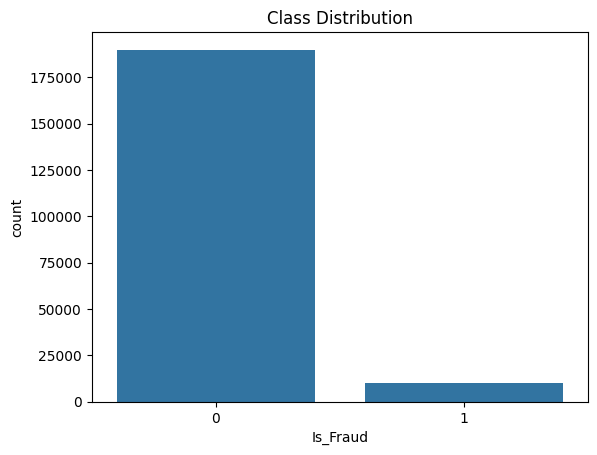

In [3]:
#Exploration of dataset
print(fraud_df.shape)
print(fraud_df.info())
print(fraud_df['Is_Fraud'].value_counts(normalize=True))

# Visualize class imbalance
sns.countplot(x='Is_Fraud', data=fraud_df)
plt.title("Class Distribution")
plt.show()


In [4]:
fraud_df.describe()

,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


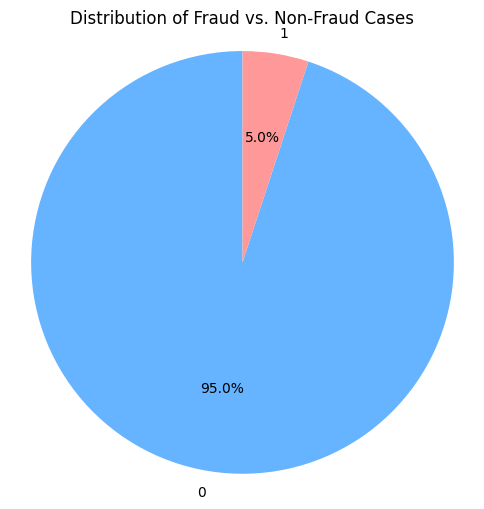

In [5]:
# Get class distribution proportions
fraud_class_distribution = fraud_df['Is_Fraud'].value_counts(normalize=True)

# Pie chart of fraud vs. non-fraud
plt.figure(figsize=(6, 6))
plt.pie(fraud_class_distribution, labels=fraud_class_distribution.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Distribution of Fraud vs. Non-Fraud Cases')
plt.axis('equal')  # Equal aspect ratio ensures the pie is a circle
plt.show()


Calculating the number of missing values for each column.

In [6]:
fraud_df.isnull().sum()

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

In [7]:
#Hnadling missing values
fraud_df = fraud_df.dropna()  # drops rows with any null value
fraud_df.isnull().sum()

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

In [8]:
#getting  categorical features
fraud_df.select_dtypes(include=['object']).columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Merchant_ID', 'Transaction_Type',
       'Merchant_Category', 'Transaction_Device', 'Transaction_Location',
       'Device_Type', 'Transaction_Currency', 'Customer_Contact',
       'Transaction_Description', 'Customer_Email'],
      dtype='object')

In [9]:
#Dropping unwanted features
fraud_df.drop(columns=['Customer_ID', 'Customer_Name', 'Transaction_ID', 'Customer_Contact','Customer_Email'], inplace=True)
fraud_df

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Date,Transaction_Time,Transaction_Amount,Merchant_ID,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Transaction_Description
0,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,23-01-2025,16:04:07,32415.45,214e03c5-5c34-40d1-a66c-f440aa2bbd02,Transfer,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,Bitcoin transaction
1,Female,51,Maharashtra,Nashik,Nashik Branch,Business,11-01-2025,17:14:53,43622.60,f9e3f11f-28d3-4199-b0ca-f225a155ede6,Bill Payment,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,Grocery delivery
2,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,25-01-2025,03:09:52,63062.56,97977d83-5486-4510-af1c-8dada3e1cfa0,Bill Payment,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,Mutual fund investment
3,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,19-01-2025,12:27:02,14000.72,f45cd6b3-5092-44d0-8afb-490894605184,Debit,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,Food delivery
4,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,30-01-2025,18:30:46,18335.16,70dd77dd-3b00-4b2c-8ebc-cfb8af5f6741,Transfer,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,Debt repayment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,Female,55,Dadra and Nagar Haveli and Daman and Diu,Diu,Diu Branch,Business,08-01-2025,18:42:09,98513.74,72817d4a-830b-4d16-bf74-244dccfe4cc4,Credit,Restaurant,37475.11,Desktop/Laptop,"Diu, Dadra and Nagar Haveli and Daman and Diu",ATM,0,INR,ATM withdrawal
199996,Male,51,Manipur,Kangpokpi,Kangpokpi Branch,Business,01-01-2025,20:51:21,40593.55,087718f9-1faa-44ef-b162-24d20ddc903c,Withdrawal,Groceries,53037.20,ATM,"Kangpokpi, Manipur",ATM,0,INR,Subscription box
199997,Female,41,Chandigarh,Chandigarh,Chandigarh Branch,Savings,28-01-2025,10:47:40,61579.70,a313cfbc-ef3d-4e59-8347-a948ac292a6f,Withdrawal,Health,96225.36,ATM,"Chandigarh, Chandigarh",Desktop,0,INR,Charity donation
199998,Female,28,Telangana,Nizamabad,Nizamabad Branch,Checking,08-01-2025,06:26:41,39488.22,08ef8813-dea0-42bf-9df5-0a63fe07673d,Debit,Electronics,89599.90,Voice Assistant,"Nizamabad, Telangana",Desktop,0,INR,Tourist attraction payment


In [10]:
# Target separation
X = fraud_df.drop(columns=['Is_Fraud'])
y = fraud_df['Is_Fraud']


In [11]:
# Encode categorical features
#Label encoding
for col in X.select_dtypes(include='object'):
    X[col] = X[col].astype('category').cat.codes

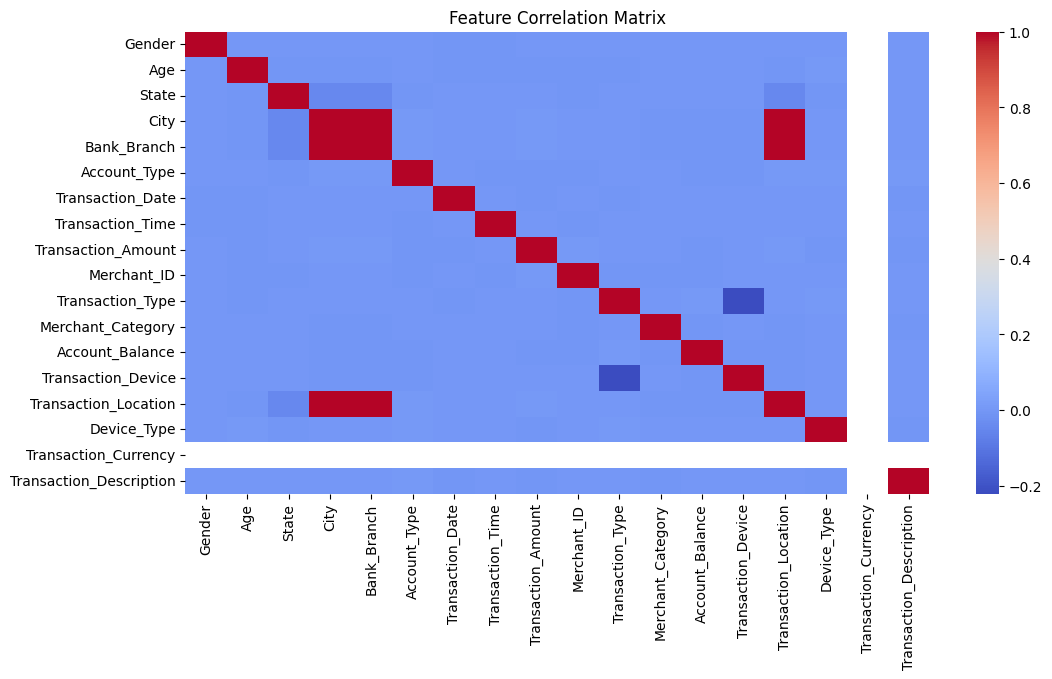

In [12]:
# Correlation matrix
plt.figure(figsize=(12, 6))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [13]:
#Normalization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


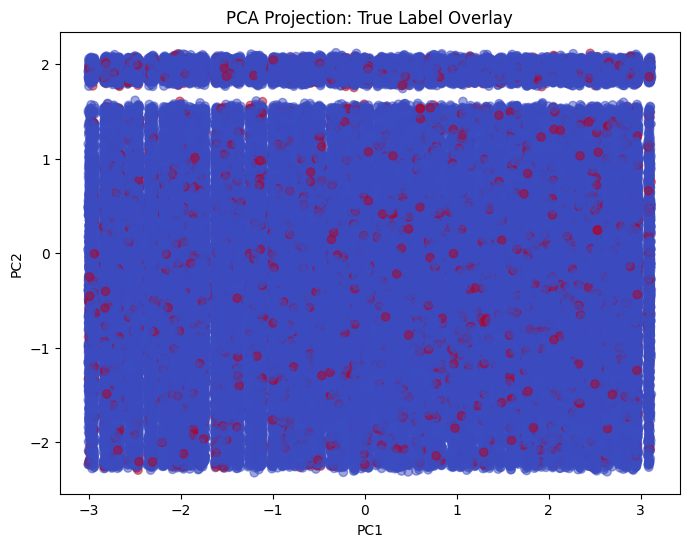

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], c=y, cmap='coolwarm', alpha=0.5)
plt.title("PCA Projection: True Label Overlay")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [15]:
print("""📊 Interpretation of the PCA Scatter Plot
No clear cluster separation: Fraud and non-fraud instances (based on color overlay) seem highly overlapping across both principal components.

Dense central blob: The majority of your data lies in the central region, showing high feature similarity across samples.

Low visual separability: This supports your earlier findings—Isolation Forest couldn’t isolate fraud because the "anomalous" patterns are subtle or drowned in noise.

🧠 What This Tells Us
The feature space (post-scaling and encoding) isn't naturally separable in 2D PCA space.

This doesn't mean the signal is absent—it may be nonlinear or buried in higher dimensions.

Isolation-based methods won't perform well here in isolation (pun intended)—but they may still help as inputs to a supervised pipeline.""")

📊 Interpretation of the PCA Scatter Plot
No clear cluster separation: Fraud and non-fraud instances (based on color overlay) seem highly overlapping across both principal components.

Dense central blob: The majority of your data lies in the central region, showing high feature similarity across samples.

Low visual separability: This supports your earlier findings—Isolation Forest couldn’t isolate fraud because the "anomalous" patterns are subtle or drowned in noise.

🧠 What This Tells Us
The feature space (post-scaling and encoding) isn't naturally separable in 2D PCA space.

This doesn't mean the signal is absent—it may be nonlinear or buried in higher dimensions.

Isolation-based methods won't perform well here in isolation (pun intended)—but they may still help as inputs to a supervised pipeline.


In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import time
import numpy as np
import pandas as pd

start = time.time()

# Parameter grid
param_grid = {
    'n_estimators': [50],
    'max_samples': ['auto'],
    'contamination': [0.05, 0.1, 0.15, 0.2]
}

best_model = None
best_f1 = 0
results = []

for n in param_grid['n_estimators']:
    for s in param_grid['max_samples']:
        for c in param_grid['contamination']:
            iso = IsolationForest(
                n_estimators=n,
                max_samples=s,
                contamination=c,
                n_jobs=-1,
                random_state=42
            )
            iso.fit(X_scaled)
            iso_scores = iso.decision_function(X_scaled)  # Higher is more normal

            # Use dynamic threshold (e.g., bottom 5% most "anomalous" scores)
            threshold = np.percentile(iso_scores, 5)
            preds = (iso_scores < threshold).astype(int)

            f1 = f1_score(y, preds)
            precision = precision_score(y, preds)
            recall = recall_score(y, preds)
            auc = roc_auc_score(y, iso_scores)

            results.append({
                'n_estimators': n,
                'max_samples': s,
                'contamination': c,
                'F1': f1,
                'Precision': precision,
                'Recall': recall,
                'ROC_AUC': auc,
                'Threshold': threshold
            })

            if f1 > best_f1:
                best_f1 = f1
                best_model = iso
                best_preds = preds
                best_scores = iso_scores

print(f"✅ Search completed in {round(time.time() - start, 2)} seconds")

# Show best results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1', ascending=False)
print(results_df)


✅ Search completed in 22.84 seconds
   n_estimators max_samples  contamination       F1  Precision    Recall  \
0            50        auto           0.05  0.05217     0.0524  0.051943   
1            50        auto           0.10  0.05217     0.0524  0.051943   
2            50        auto           0.15  0.05217     0.0524  0.051943   
3            50        auto           0.20  0.05217     0.0524  0.051943   

    ROC_AUC     Threshold  
0  0.498308 -2.194073e-17  
1  0.498308 -9.014290e-03  
2  0.498308 -1.503246e-02  
3  0.498308 -1.988378e-02  


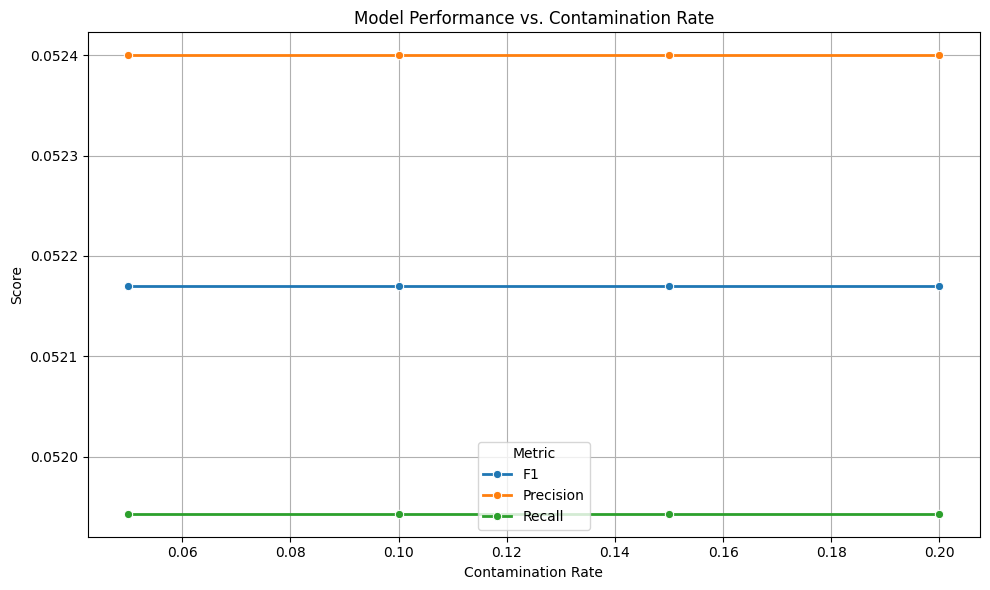

In [17]:
# Melt the DataFrame for seaborn multi-line plotting
melted = results_df.melt(id_vars='contamination', value_vars=['F1', 'Precision', 'Recall'],
                         var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=melted, x='contamination', y='Score', hue='Metric', marker='o', linewidth=2)

plt.title('Model Performance vs. Contamination Rate')
plt.xlabel('Contamination Rate')
plt.ylabel('Score')
plt.grid(True)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [18]:
#Train test and split for autoencoder
X_train_ae, X_val_ae = train_test_split(X_scaled, test_size=0.2, random_state=42)


In [ ]:
%pip install tensorflow



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
#Building autoencoder
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam

# Define architecture
input_dim = X_train_ae.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(encoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')


In [21]:
#Train autoencoder
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_val_ae, X_val_ae),
    verbose=1
)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.2549 - val_loss: 0.0699
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0545 - val_loss: 0.0392
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0103 - val_loss: 0.0017
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 8.1996e-04 - val_loss: 3.5316e-04
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 2.3525e-04 - val_loss: 2.5847e-04
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 1.3188e-04 - val_loss: 9.4539e-05
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 9.5898e-05 - val_loss: 7.6990e-05
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 8.7958e-05 - val_loss: 3.9502e-05
Epoch 9/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 7.4270e-05 - val_loss: 4.3279e-05
Epoch 10/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 7.0844e-05 - val_loss: 5.3929e-05
Epoch 11/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 7

In [22]:
# Predict reconstructed values
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step


In [23]:
# Pseudo Labels
threshold = np.percentile(mse, 97)  # Top 3% most anomalous
pseudo_fraud = (mse > threshold).astype(int)


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_23200\2156194930.py:10: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


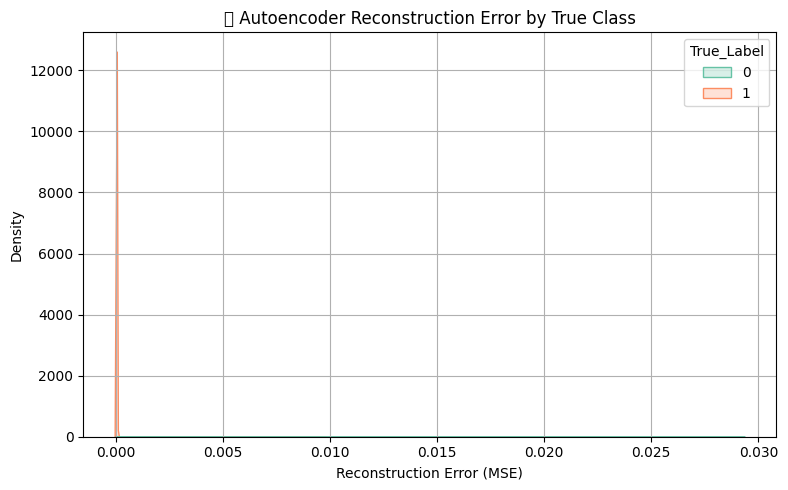

In [24]:
# Create a DataFrame for visualization
ae_scores = pd.DataFrame({'Reconstruction_Error': mse, 'True_Label': y})

plt.figure(figsize=(8, 5))
sns.kdeplot(data=ae_scores, x='Reconstruction_Error', hue='True_Label', fill=True, common_norm=False, palette='Set2')
plt.title("🔍 Autoencoder Reconstruction Error by True Class")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
# Use only legitimate (non-fraud) transactions for training
X_normal = X_scaled[y == 0]


In [26]:
#Rebuilding and retraining autoencoder
# Define deeper architecture
input_dim = X_train_ae.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=Adam(0.001), loss='mse')

# Train only on normal transactions
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=25,
    batch_size=256,
    shuffle=True,
    validation_data=(X_val_ae, X_val_ae),
    verbose=1
)


Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.2063 - val_loss: 0.0317
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0096 - val_loss: 0.0038
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9.6645e-04 - val_loss: 4.7726e-04
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5.8040e-04 - val_loss: 2.3364e-04
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 4.2017e-04 - val_loss: 1.3630e-04
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 3.2660e-04 - val_loss: 2.4621e-04
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 2.9461e-04 - val_loss: 1.8254e-04
Epoch 9/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 2.6504e-04 - val_loss: 2.9520e-04
Epoch 10/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 2.5934e-04 - val_loss: 6.4809e-04
Epoch 11/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 

In [27]:
reconstructions = autoencoder.predict(X_scaled)
recon_error = np.mean(np.square(X_scaled - reconstructions), axis=1)


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_23200\2564655605.py:13: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


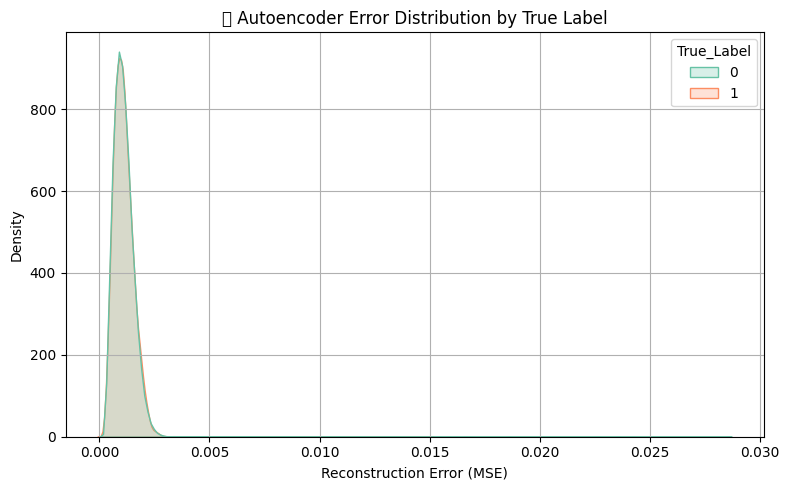

In [28]:
# Create DataFrame for visualization
ae_df = pd.DataFrame({
    'Reconstruction_Error': recon_error,
    'True_Label': y
})

plt.figure(figsize=(8, 5))
sns.kdeplot(data=ae_df, x='Reconstruction_Error', hue='True_Label', fill=True, common_norm=False, palette='Set2')
plt.title("🧠 Autoencoder Error Distribution by True Label")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_23200\835882086.py:11: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


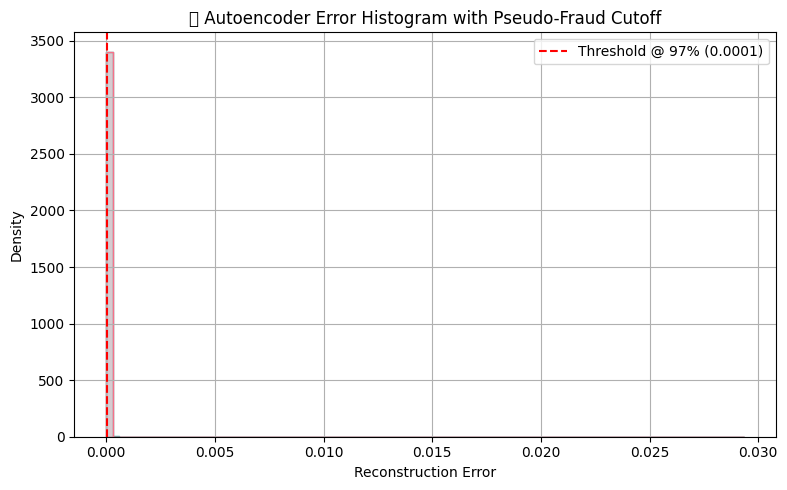

Note: This is not constant, it varies at any time instance base on the set of data the model works with at that time instance


In [29]:
threshold = np.percentile(mse, 97)  # Use the actual threshold you're applying

plt.figure(figsize=(8, 5))
sns.histplot(ae_scores, x='Reconstruction_Error', hue='True_Label', bins=100, palette='husl', element='step', stat='density', common_norm=False)
plt.axvline(threshold, color='red', linestyle='--', label=f"Threshold @ 97% ({threshold:.4f})")
plt.title("🚨 Autoencoder Error Histogram with Pseudo-Fraud Cutoff")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print('Note: This is not constant, it varies at any time instance base on the set of data the model works with at that time instance')


In [30]:
# Label the bottom 3% most anomalous points as fraud

threshold = np.percentile(iso_scores, 3)
pseudo_fraud = (iso_scores < threshold).astype(int)

print("Pseudo-fraud label counts:", np.unique(pseudo_fraud, return_counts=True))


Pseudo-fraud label counts: (array([0, 1]), array([194000,   6000]))


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

# === 1. Fit KMeans ===
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# === 2. Compute distances from assigned centroids ===
centroids = kmeans.cluster_centers_
assigned_centroids = centroids[kmeans_labels]
distances = np.linalg.norm(X_scaled - assigned_centroids, axis=1)

# === 3. Flag top 1% farthest points as anomalies ===
threshold = np.percentile(distances, 99)
kmeans_anomaly = (distances >= threshold).astype(int)

# === 4. Evaluate vs. true labels ===
f1_k = f1_score(y, kmeans_anomaly)
precision_k = precision_score(y, kmeans_anomaly)
recall_k = recall_score(y, kmeans_anomaly)

# Save for comparison DataFrame
kmeans_results = pd.DataFrame([{
    'Model': 'KMeans',
    'F1': f1_k,
    'Precision': precision_k,
    'Recall': recall_k
}])


In [32]:
# === Evaluate Autoencoder Signal ===
auto_threshold = np.percentile(recon_error, 97)  # Top 3% most anomalous
autoenc_anomaly = (recon_error > auto_threshold).astype(int)

f1_ae = f1_score(y, autoenc_anomaly)
precision_ae = precision_score(y, autoenc_anomaly)
recall_ae = recall_score(y, autoenc_anomaly)

autoenc_results = pd.DataFrame([{
    'Model': 'Autoencoder',
    'F1': f1_ae,
    'Precision': precision_ae,
    'Recall': recall_ae
}])

# === Reformat Isolation Forest (best run) ===
isolation_forest_summary = results_df.sort_values(by='F1', ascending=False).head(1).copy()
isolation_forest_summary['Model'] = 'Isolation Forest'
isolation_forest_summary = isolation_forest_summary[['Model', 'F1', 'Precision', 'Recall']]

# === Existing KMeans results ===
kmeans_results = pd.DataFrame([{
    'Model': 'KMeans',
    'F1': f1_k,
    'Precision': precision_k,
    'Recall': recall_k
}])

# === Combine All Results ===
comparison_df = pd.concat([
    isolation_forest_summary,
    kmeans_results,
    autoenc_results
], ignore_index=True)

# === Display Leaderboard ===
print("🔍 Unsupervised Model Comparison:")
print(comparison_df.sort_values(by='F1', ascending=False))


🔍 Unsupervised Model Comparison:
              Model        F1  Precision    Recall
0  Isolation Forest  0.052170   0.052400  0.051943
2       Autoencoder  0.039035   0.052333  0.031126
1            KMeans  0.017538   0.053000  0.010508


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_23200\1514614062.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


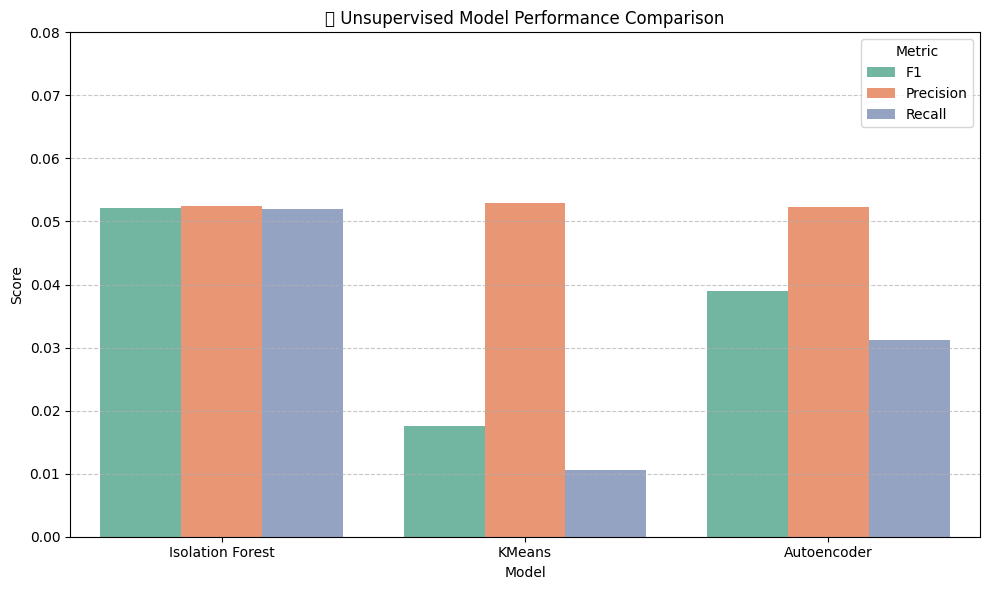

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse your comparison_df
melted = comparison_df.melt(id_vars='Model', value_vars=['F1', 'Precision', 'Recall'],
                            var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted, x='Model', y='Score', hue='Metric', palette='Set2')

plt.title("🔍 Unsupervised Model Performance Comparison")
plt.ylim(0, 0.08)
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


FEATURE FUSION(HYBRIDIZATION)

In [34]:
# Start with your encoded + scaled features
X_hybrid = pd.DataFrame(X_scaled, columns=X.columns)

# Add anomaly signals
X_hybrid['iso_score'] = iso.decision_function(X_scaled)
X_hybrid['autoenc_error'] = recon_error
X_hybrid['kmeans_flag'] = kmeans_anomaly

# Optional: normalize scores if needed
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# X_hybrid[['iso_score', 'autoenc_error']] = scaler.fit_transform(X_hybrid[['iso_score', 'autoenc_error']])


SUPERVISED LEARNING

In [35]:
#Train-Test Split (Stratified)
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss.split(X_hybrid, y):
    X_train, X_test = X_hybrid.iloc[train_idx], X_hybrid.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [36]:
#Train Random Forest (with Class Balancing)
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',  # Helps with fraud imbalance
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # For ROC-AUC


In [37]:
#Evaluation performance
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

auc = roc_auc_score(y_test, y_prob)
print(f"🔍 ROC-AUC Score: {auc:.4f}")


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.9496    0.9846    0.9668     37982
           1     0.0519    0.0159    0.0243      2018

    accuracy                         0.9357     40000
   macro avg     0.5008    0.5002    0.4955     40000
weighted avg     0.9043    0.9357    0.9192     40000

🔍 ROC-AUC Score: 0.5032


In [38]:
#XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss.split(X_hybrid, y):
    X_train, X_test = X_hybrid.iloc[train_idx], X_hybrid.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),  # balance classes
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

clf.fit(X_train, y_train)


c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:16:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [39]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("📋 XGBoost Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

auc = roc_auc_score(y_test, y_prob)
print(f"🔍 ROC-AUC Score: {auc:.4f}")


📋 XGBoost Classification Report:
              precision    recall  f1-score   support

           0     0.9507    0.7460    0.8360     37982
           1     0.0538    0.2721    0.0899      2018

    accuracy                         0.7220     40000
   macro avg     0.5023    0.5090    0.4629     40000
weighted avg     0.9055    0.7220    0.7983     40000

🔍 ROC-AUC Score: 0.5075


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_23200\3244863532.py:11: UserWarning: Glyph 129518 (\N{ABACUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 600x500 with 0 Axes>

c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129518 (\N{ABACUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


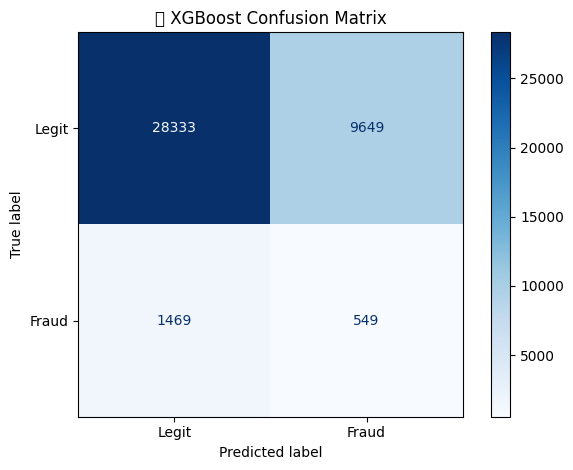

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("🧮 XGBoost Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()


100%|===================| 39983/40000 [30:34<00:00]        

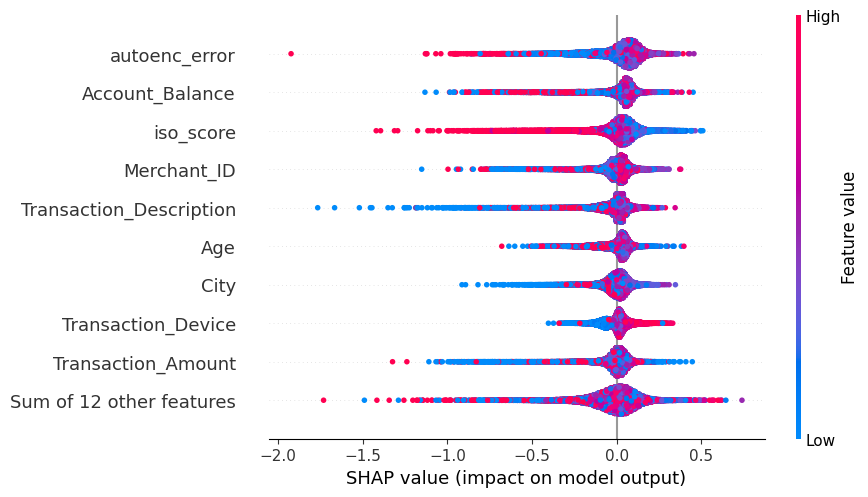

In [41]:
import shap

# Create explainer using training set (sample if needed)
explainer = shap.Explainer(clf, X_train, feature_names=X_train.columns)
shap_values = explainer(X_test)

# Summary plot
shap.plots.beeswarm(shap_values, max_display=10)


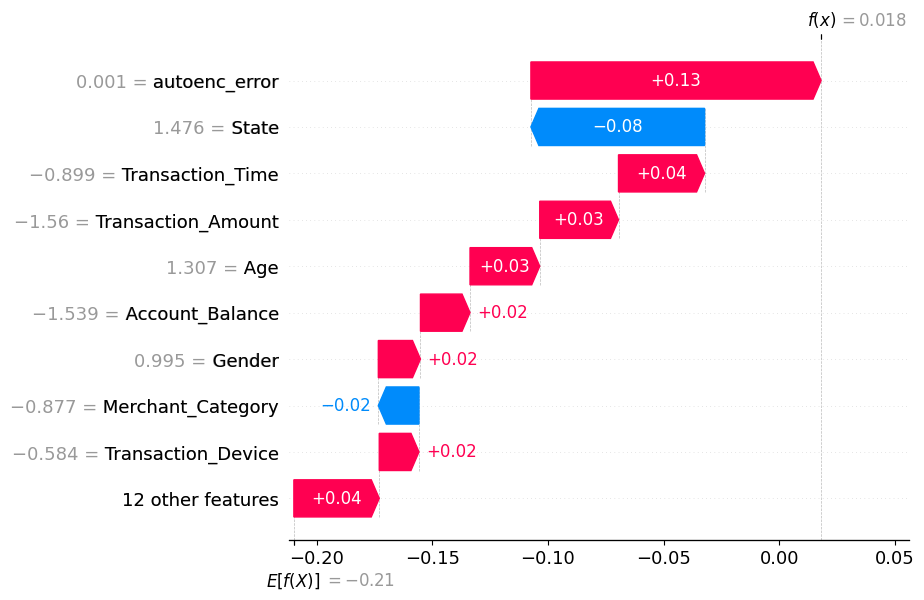

In [42]:
# Find an example that was predicted as fraud (class = 1)
fraud_index = np.where((y_test.values == 1) & (y_pred == 1))[0][0]  # Just take the first one

# Explain that single prediction
shap.initjs()
shap.plots.waterfall(shap_values[fraud_index], max_display=10)


In [43]:
import joblib

# Save these to disk (adjust names as needed)
joblib.dump(clf, "xgb_model.pkl")
joblib.dump(iso, "iso_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
joblib.dump(scaler, "scaler.pkl")  # if you used one


['scaler.pkl']

In [44]:
# Replace 'df' with the name of your main dataset if different
X_raw = fraud_df.drop('Is_Fraud', axis=1)
y_raw = fraud_df['Is_Fraud']


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

# === 1. Config ===
selected_features = ['Account_Balance', 'Age', 'Transaction_Device', 'Merchant_ID', 'Transaction_Amount']
numeric_features = ['Account_Balance', 'Age', 'Transaction_Amount']
categorical_features = ['Transaction_Device', 'Merchant_ID']

# === 2. Fit Isolation Forest ===
iso_scaler = StandardScaler()
X_scaled_numeric = iso_scaler.fit_transform(X_raw[numeric_features])
iso_model = IsolationForest(contamination=0.02, random_state=42)
iso_model.fit(X_scaled_numeric)

# === 3. Custom transformer for iso_score ===
class AnomalyAdder(BaseEstimator, TransformerMixin):
    def __init__(self, iso_model, numeric_cols, scaler):
        self.iso_model = iso_model
        self.numeric_cols = numeric_cols
        self.scaler = scaler

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        scaled = self.scaler.transform(X[self.numeric_cols])
        X['iso_score'] = self.iso_model.decision_function(scaled)
        X['autoenc_error'] = 0.0  # placeholder
        X['kmeans_flag'] = 0      # placeholder
        return X

# === 4. Preprocessor: scale num + encode cat ===
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features + ['iso_score', 'autoenc_error', 'kmeans_flag']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# === 5. Classifier ===
clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# === 6. Build the pipeline ===
pipeline = Pipeline(steps=[
    ('add_anomalies', AnomalyAdder(iso_model, numeric_features, iso_scaler)),
    ('preprocess', preprocessor),
    ('classifier', clf)
])

# === 7. Fit it ===
X = X_raw[selected_features]
y = y_raw
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
pipeline.fit(X_train, y_train)



,steps,"[('add_anomalies', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,iso_model,IsolationFore...ndom_state=42)
,numeric_cols,"['Account_Balance', 'Age', ...]"
,scaler,StandardScaler()
,n_estimators,100
,max_samples,'auto'
,contamination,0.02
,max_features,1.0


In [46]:

# === 8. Save the pipeline + input schema ===
joblib.dump(pipeline, "fraud_detector_pipeline.pkl")
joblib.dump(selected_features, "model_input_features.pkl")
print("✅ Pipeline saved successfully")

✅ Pipeline saved successfully


In [47]:
import joblib
import pandas as pd

# Load model and features
pipeline = joblib.load("fraud_detector_pipeline.pkl")
input_features = joblib.load("model_input_features.pkl")

# Get all possible categories for categorical features from the training data
# This assumes the pipeline was trained on the full dataset or a representative sample
# Extracting categories from the fitted OneHotEncoder within the pipeline
try:
    ohe = pipeline.named_steps['preprocess'].named_transformers_['cat']
    all_categories = ohe.categories_
    categorical_cols_in_pipeline = [col for col in pipeline.named_steps['preprocess'].transformers if col[0] == 'cat'][0][2]
    category_map = dict(zip(categorical_cols_in_pipeline, all_categories))

except Exception as e:
    print(f"Could not extract categories from the pipeline: {e}")
    # Fallback: If extraction fails, use a predefined list of possible categories
    category_map = {
        'Transaction_Device': ['Voice Assistant', 'POS Mobile Device', 'ATM', 'POS Mobile App', 'Virtual Card', 'Self-service Banking Machine', 'Tablet', 'Debit/Credit Card', 'Wearable Device', 'ATM Booth Kiosk', 'Mobile Device', 'Web Browser', 'Banking Chatbot', 'POS Terminal', 'Online Banking Portal', 'Kiosk', 'Smart Card', 'Other'],
        'Merchant_ID': [] # Merchant_ID has too many unique values, will rely on handle_unknown='ignore'
    }


def predict_transaction(user_input: dict) -> dict:
    """
    Minimal expected user input:
    'Account_Balance', 'Transaction_Amount', 'State',
    'Transaction_Time', 'Age', 'Transaction_Device'
    """
    # Create a DataFrame with potentially missing columns, adding all possible categories for OHE
    data = {}
    for col in input_features:
        if col in user_input:
            data[col] = [user_input[col]]
        elif col in category_map:
             # Add all possible categories to ensure one-hot encoder sees them
            data[col] = [user_input.get(col, 'Unknown')] # Use 'Unknown' or a sensible default
        else:
            data[col] = [0] # Default for numerical/other features

    df = pd.DataFrame(data)

    # Default engineered or unused inputs (ensure these are in input_features if used in pipeline)
    if 'autoenc_error' not in df.columns:
        df['autoenc_error'] = user_input.get('autoenc_error', 0.04)
    if 'iso_score' not in df.columns:
        df['iso_score'] = user_input.get('iso_score', -0.15)
    if 'kmeans_flag' not in df.columns: # Added kmeans_flag based on pipeline preprocessor
         df['kmeans_flag'] = user_input.get('kmeans_flag', 0)

    # Ensure all required columns are present and in the correct order
    for col in input_features:
        if col not in df.columns:
            df[col] = 0 # Add missing columns with a default value

    df = df[input_features]


    prob = pipeline.predict_proba(df)[0][1]
    pred = int(prob >= 0.1)

    return {
        "Prediction": "⚠️ Fraud Detected" if pred else "✅ Legit Transaction",
        "Probability": round(prob, 4),
        "Threshold": 0.25
    }

In [48]:
test_input = {
    'Account_Balance': 8780.50,
    'Transaction_Amount': 45,
    'State': 'Western',
    'Transaction_Time': 21.45,
    'Age': 34,
    'Transaction_Device': 'POS'
}

result = predict_transaction(test_input)
print(result)

{'Prediction': '✅ Legit Transaction', 'Probability': np.float64(0.04), 'Threshold': 0.25}
